(misspecified_recovery)=
```{raw} html
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 误设定下的恢复

```{contents} Contents
:depth: 2
```

## 概述

讲座 {doc}`ross_recovery` 研究了恢复有效的情形。

在那里，**转移独立性**让我们能够使用阿罗价格将投资者的信念与定价核分离开来。

本讲座探讨当不施加该限制时，相同的佩龙-弗罗贝尼乌斯方法会给出什么结果。

我们将保持三个概率测度相互分离。

第一个是正确设定的概率测度，它支配着模型中的马尔可夫状态。

第二个是单期风险中性概率测度，它来自用债券价格对单期阿罗价格进行归一化。

第三个是通过佩龙-弗罗贝尼乌斯理论恢复的概率测度，也称为长期风险中性测度。

核心问题是恢复的概率测度是否等于正确设定的概率测度。

{cite:t}`BorovickaHansenScheinkman2016` 表明，一般而言，答案是否定的。

该论文研究了恢复的概率测度与正确设定的概率测度之比。

原因在于随机贴现因子可能包含一个改变概率测度的鞅成分。

如果该鞅成分恒等于一，Ross 恢复会返回正确设定的转移概率。

如果它不恒等于一，恢复的概率测度会吸收长期风险调整，因为鞅增量沿历史路径复合。

在下面的例子中，恢复的概率测度对不利长期风险状态赋予的概率比正确设定的概率测度更多。

我们将：

- 使用 {doc}`ross_recovery` 的结论而不重新证明它，
- 通过鞅成分研究误设定，
- 说明为什么递归效用和永久冲击会使恢复的概率测度不同于正确设定的概率测度，
- 在长期风险模型中度量这种差异。

我们将使用以下导入。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg
from scipy.integrate import solve_ivp
from scipy.stats import gaussian_kde
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

下一个单元包含从上一讲座继承的代码。

它对阿罗价格进行行归一化，找到佩龙-弗罗贝尼乌斯特征值和正的右特征向量，并计算平稳分布。

In [2]:
def risk_neutral_probs(Q):
    """用单期债券价格对阿罗价格进行归一化。"""
    q_bonds = Q.sum(axis=1)
    P_bar = Q / q_bonds[:, None]
    return P_bar, q_bonds


def perron_frobenius(Q):
    """佩龙-弗罗贝尼乌斯特征对及相关的转移矩阵。"""
    eigenvalues, eigenvectors = linalg.eig(Q)
    eigenvalues = np.real_if_close(eigenvalues, tol=1000)
    eigenvectors = np.real_if_close(eigenvectors, tol=1000)

    real_mask = np.isreal(eigenvalues)
    vals = np.asarray(eigenvalues[real_mask].real, dtype=float)
    vecs = np.asarray(eigenvectors[:, real_mask].real, dtype=float)

    for idx in np.argsort(vals)[::-1]:
        exp_eta = vals[idx]
        e = vecs[:, idx]
        if e.sum() < 0:
            e = -e
        if exp_eta > 0 and np.all(e > 0):
            break
    else:
        raise ValueError("No strictly positive Perron-Frobenius eigenvector found")

    e = e / e.sum()
    eta = np.log(exp_eta)
    P_hat = (1 / exp_eta) * Q * e[None, :] / e[:, None]

    if np.max(np.abs(P_hat.sum(axis=1) - 1)) > 1e-8:
        raise ValueError("Recovered transition matrix is not stochastic")
    if P_hat.min() < -1e-10:
        raise ValueError("Recovered transition matrix has negative entries")

    return eta, exp_eta, e, P_hat


def stationary_dist(P):
    """遍历转移矩阵的平稳分布。"""
    n = P.shape[0]
    A = P.T - np.eye(n)
    A[-1] = 1
    b = np.zeros(n)
    b[-1] = 1
    return linalg.solve(A, b)


def martingale_increment(Q, P):
    """恢复的概率测度的鞅增量。"""
    eta, exp_eta, e, P_hat = perron_frobenius(Q)
    H = np.ones_like(P)
    mask = P > 0
    H[mask] = P_hat[mask] / P[mask]
    return H, eta, e, P_hat

## 三个转移矩阵

设 $\mathbf{P}=[p_{ij}]$ 表示正确设定的转移矩阵，$\mathbf{Q}=[q_{ij}]$ 表示阿罗价格矩阵。

这里"正确设定"意味着 $\mathbf{P}$ 是支配模型中马尔可夫状态的转移矩阵。

单期随机贴现因子（SDF）满足

```{math}
:label: eq-mr-arrow-price-finite

q_{ij} = s_{ij} p_{ij}.
```

我们将把 $\mathbf{P}$ 与由 $\mathbf{Q}$ 构造的两个概率矩阵进行比较。

第一个是**单期风险中性矩阵**。

它将 $\mathbf{Q}$ 的每一行除以当前状态下单期贴现债券的价格：

$$
\bar p_{ij}
= \frac{q_{ij}}{\sum_k q_{ik}}.
$$

这个矩阵将单期风险调整吸收进转移概率中。

第二个是与**长期风险中性概率**相关的转移矩阵。

它从 $\mathbf{Q}$ 的佩龙-弗罗贝尼乌斯特征值和正的右特征向量出发。

设 $(\exp(\hat \eta), \hat e)$ 满足

```{math}
:label: eq-mr-pf-finite

\mathbf{Q}\hat e = \exp(\hat \eta)\hat e.
```

然后定义

```{math}
:label: eq-mr-phat-finite

\hat p_{ij}
= \exp(-\hat \eta) q_{ij} \frac{\hat e_j}{\hat e_i}.
```

选择因子 $\hat e_j/\hat e_i$ 是为了抵消任何形如 $\exp(\hat \eta)\hat e_i/\hat e_j$ 的 SDF 成分。

结果是一个随机矩阵 $\hat{\mathbf{P}}$。

这一构造假设 $\mathbf{Q}$ 在相差一个比例因子的意义下有唯一的正右特征向量。

对于有限的不可约非负矩阵，佩龙根有一个在相差比例因子意义下唯一的严格正右特征向量。

对于长视界的支配性和收敛性，通常会施加更强的条件，如原始性或非周期性；该论文使用了对 $\sum_{t=0}^{\infty}\lambda^t\mathbf Q^t$ 的正性条件。

在一般状态空间中，这一保证不再成立：可能存在多个正特征函数，需要额外的选择条件来确定长期风险中性测度。

下一节的一般框架使该选择条件变得明确。

遵循 {cite:t}`BorovickaHansenScheinkman2016`，$\hat{\mathbf{P}}$ 被称为**长期风险中性**转移矩阵。

这个名称意味着佩龙-弗罗贝尼乌斯特征值和特征向量分离出了在长期限阿罗债权定价中占支配地位的部分。

它与单期风险中性矩阵 $\bar{\mathbf{P}}$ 不是同一个转移矩阵。

在 {doc}`ross_recovery` 中，转移独立性将 SDF 限制为

$$
s_{ij}=\exp(-\delta)\frac{m_j}{m_i}
$$

其中 $m$ 是正向量，$\delta$ 是标量，这确定了 $s_{ij}$ 与 $p_{ij}$ 之间的划分。

在这里我们放弃这一限制。

问题是与长期风险中性概率相关的转移矩阵 $\hat{\mathbf{P}}$ 是否仍然等于正确设定的矩阵 $\mathbf{P}$。

### 退化的鞅成分

我们从一个三状态经济开始：衰退、正常和扩张。

正确设定的转移矩阵故意设置得很简单。

对于趋势平稳消费和幂效用，SDF 为

$$
s_{ij}=A\left(\frac{c_j}{c_i}\right)^{-\gamma}.
$$

这是 Ross 恢复应该返回正确设定的转移矩阵的一个情形。

In [3]:
P_true = np.array([
    [0.70, 0.25, 0.05],
    [0.15, 0.65, 0.20],
    [0.05, 0.30, 0.65],
])

c_levels = np.array([0.997, 1.000, 1.003])
state_names = ['衰退', '正常', '扩张']

δ = -np.log(0.99)   # 月度主观贴现率
γ_power = 5.0       # 风险厌恶
g_c = 0.002         # 月度趋势增长

# 用实际概率乘以幂效用 SDF 来给阿罗债权定价
S_power = (
    np.exp(-δ - γ_power * g_c)
    * (c_levels[None, :] / c_levels[:, None])**(-γ_power)
)
Q_power = S_power * P_true

我们现在从同一个阿罗价格矩阵计算单期风险中性矩阵和与长期风险中性概率相关的转移矩阵。

In [4]:
P_bar, q_bonds = risk_neutral_probs(Q_power)
η_hat, exp_η, e_hat, P_hat = perron_frobenius(Q_power)
π_true = stationary_dist(P_true)
π_bar = stationary_dist(P_bar)
π_hat = stationary_dist(P_hat)

这两个矩阵不应被期望是一致的。

行归一化矩阵 $\bar{\mathbf{P}}$ 是一个短视界风险中性测度变换：它将单期 SDF 折叠进转移概率中，因此它通常不同于正确设定的矩阵 $\mathbf{P}$。

其逻辑来自 {doc}`ross_recovery` 中的佩龙-弗罗贝尼乌斯构造。

在转移独立的情形中，定价核具有形式 $s_{ij}=\exp(\hat\eta)\hat e_i/\hat e_j$。

将其代入佩龙-弗罗贝尼乌斯转移公式得到

$$
\hat p_{ij}
= \exp(-\hat\eta) q_{ij}\frac{\hat e_j}{\hat e_i}
= \exp(-\hat\eta)
  \left(\exp(\hat\eta)\frac{\hat e_i}{\hat e_j}p_{ij}\right)
  \frac{\hat e_j}{\hat e_i}
=p_{ij}.
$$

因此，与长期风险中性概率相关的转移矩阵 $\hat{\mathbf{P}}$ 抵消了 SDF 中转移独立的部分。

在这个幂效用基准中，整个 SDF 恰好具有这种形式，因此剩余的鞅增量应为一，$\hat{\mathbf{P}}$ 应与 $\mathbf{P}$ 一致。

下一个计算通过将佩龙-弗罗贝尼乌斯特征函数与 $c_i^\gamma$ 进行比较，然后计算比值 $\hat{\mathbf{P}}/\mathbf{P}$ 来验证这一点。

定义单期鞅增量

$$
\hat h_{ij}
= \frac{\hat p_{ij}}{p_{ij}}
= \exp(-\hat\eta)s_{ij}\frac{\hat e_j}{\hat e_i}.
$$

当对每个转移都有 $\hat h_{ij}=1$ 时，$\hat{\mathbf P}$ 和 $\mathbf P$ 相同。

下一节解释为什么这个比值是单期鞅增量。

在幂效用例子中，记

$$
A = \exp(-\delta-\gamma g_c),
\qquad
s_{ij}=A\left(\frac{c_j}{c_i}\right)^{-\gamma}.
$$

取 $\hat e_i=c_i^\gamma$（相差一个比例因子），得到

$$
[\mathbf{Q}\hat e]_i
= \sum_j A\left(\frac{c_j}{c_i}\right)^{-\gamma}p_{ij}c_j^\gamma
= A c_i^\gamma
= A\hat e_i,
$$

因此 $\exp(\hat\eta)=A$。

因此，

$$
\hat h_{ij}
= A^{-1}A\left(\frac{c_j}{c_i}\right)^{-\gamma}
  \frac{c_j^\gamma}{c_i^\gamma}
=1.
$$

In [5]:
H_power = np.divide(P_hat, P_true, out=np.ones_like(P_true), where=P_true > 0)
e_theory = c_levels**γ_power

print("佩龙-弗罗贝尼乌斯特征函数：数值 vs c^gamma")
for name, e_num, e_th in zip(state_names, e_hat / e_hat[1],
                             e_theory / e_theory[1]):
    print(f"{name:9s}: {e_num:.6f}  {e_th:.6f}")

print("\n鞅增量 h_hat = P_hat / P")
print(np.round(H_power, 6))

print("\nP 下的条件均值")
print(np.round((P_true * H_power).sum(axis=1), 6))

print(f"\nmax |h_hat - 1| = "
      f"{np.max(np.abs(H_power[P_true > 0] - 1)):.2e}")

佩龙-弗罗贝尼乌斯特征函数：数值 vs c^gamma
衰退       : 0.985090  0.985090
正常       : 1.000000  1.000000
扩张       : 1.015090  1.015090

鞅增量 h_hat = P_hat / P
[[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

P 下的条件均值
[1. 1. 1.]

max |h_hat - 1| = 2.22e-15


输出将短视界风险调整与佩龙-弗罗贝尼乌斯方法分离开来。

单期风险中性矩阵 $\bar{\mathbf{P}}$ 接近但不等于正确设定的矩阵 $\mathbf{P}$。

它改变了转移概率，因为单期阿罗价格包含了单期风险调整。

相比之下，在这个例子中，长期风险中性矩阵 $\hat{\mathbf{P}}$ 与 $\mathbf{P}$ 完全相同。

计算确认了原因：对每个转移，鞅增量 $\hat h_{ij}$ 都为一。

这是 Ross 恢复返回正确设定的转移矩阵的条件。

在这个例子中，这种抵消耗尽了 SDF，因此鞅成分是退化的。

## 鞅成分

设 $(\hat \eta, \hat e)$ 是 $\mathbf{Q}$ 的佩龙-弗罗贝尼乌斯特征值指数和正的右特征向量：

$$
\mathbf{Q} \hat e = \exp(\hat\eta) \hat e.
$$

相关的长期风险中性转移矩阵为

$$
\hat p_{ij}
= \exp(-\hat\eta) q_{ij} \frac{\hat e_j}{\hat e_i}.
$$

要看恢复是否改变了概率测度，将每个恢复的转移概率与对应的正确设定的转移概率进行比较。

对于 $p_{ij}>0$ 的可行转移，定义单期鞅增量

```{math}
:label: eq-mr-hhat-finite

\hat h_{ij} = \frac{\hat p_{ij}}{p_{ij}}.
```

如果 $\hat h_{ij}>1$，恢复的概率测度对转移 $(i,j)$ 赋予的概率比正确设定的概率测度更多。

如果 $\hat h_{ij}<1$，它对该转移赋予的概率更少。

对于固定的当前状态 $i$，在正确设定的转移概率下，数值 $\hat h_{ij}$ 的平均值为一：

$$
\sum_j \hat h_{ij} p_{ij}=1.
$$

因此 $\hat h_{ij}$ 是一个单期鞅增量。

沿着状态历史将这些增量相乘，得到整个历史的恢复概率测度与正确设定概率测度之比。

该比值过程是一个鞅，这就是为什么 {eq}`eq-mr-finite-sdf-decomposition` 中的最后一项被称为鞅成分。

使用 {eq}`eq-mr-arrow-price-finite`、{eq}`eq-mr-phat-finite` 和 {eq}`eq-mr-hhat-finite`，单期 SDF 可以写为

```{math}
:label: eq-mr-finite-sdf-decomposition

s_{ij}
= \exp(\hat\eta) \frac{\hat e_i}{\hat e_j} \hat h_{ij}.
```

因此佩龙-弗罗贝尼乌斯方法将 SDF 分离为：

| 部分 | 作用 |
|---|---|
| $\exp(\hat\eta)$ | 确定性长期贴现 |
| $\hat e_i / \hat e_j$ | 状态相关的长期项 |
| $\hat h_{ij}$ | 改变概率的鞅增量 |

如果对每个可行转移都有 $\hat h_{ij}=1$，那么与恢复的概率测度相关的转移矩阵和正确设定的转移矩阵相同。

这是 Ross 恢复返回正确设定的转移矩阵的条件。

```{prf:proposition} 有限状态鞅成分
:label: prop-misspecified-recovery-martingale-component

在本讲座使用的有限状态假设下，对于具有正确设定转移矩阵 $\mathbf{P}$ 和阿罗矩阵 $\mathbf{Q}$ 的马尔可夫模型，通过佩龙-弗罗贝尼乌斯理论恢复的概率测度返回正确设定的转移矩阵，当且仅当对每个 $p_{ij}>0$ 的转移都有 $\hat h_{ij}=1$。

等价地，恢复返回正确设定的转移矩阵，当且仅当 {eq}`eq-mr-finite-sdf-decomposition` 中的 SDF 没有非常数的鞅成分：

$$
s_{ij}=\exp(\hat\eta)\frac{\hat e_i}{\hat e_j}.
$$
```

```{prf:proof}
使用 $q_{ij}=s_{ij}p_{ij}$，

$$
\hat h_{ij}
=\frac{\hat p_{ij}}{p_{ij}}
=\exp(-\hat\eta)s_{ij}\frac{\hat e_j}{\hat e_i}.
$$

因此 $\hat{\mathbf{P}}=\mathbf{P}$ 当且仅当对每个可行转移都有 $\hat h_{ij}=1$。

这个条件等同于说 SDF 可以写成 {eq}`eq-mr-finite-sdf-decomposition` 而没有额外的鞅增量。
```

这个有限状态推论是该论文一般识别结果的一个特例。

如果一对 $(S,P)$ 能解释资产价格，且 $H$ 是一个正的乘性鞅，那么相同的资产价格也可以由改变后的概率测度 $P^H$ 连同调整后的随机贴现因子来解释

$$
S_t^H = S_t\frac{H_0}{H_t}.
$$

更一般地，任何严格正的鞅都可以改变概率测度，但乘性保持了这里使用的马尔可夫结构。

因此，仅凭阿罗价格通常无法区分信念的变化与 SDF 的变化。

Ross 恢复只有在施加某个限制之后才成为一个识别结果，例如

$$
S_t = \exp(-\delta t)\frac{m(X_t)}{m(X_0)},
$$

这排除了一个非平凡的鞅成分。

上面的幂效用例子说明了这个命题。

在那个基准中，鞅增量 $\hat h_{ij}$ 恒等于一。

## 从矩阵到一般框架

有限状态计算有三个对象：

1. 正确设定的转移概率 $p_{ij}$，
2. SDF 增量 $s_{ij}$，
3. 阿罗价格 $q_{ij}=s_{ij}p_{ij}$。

它还有一个诊断对象：

$$
\hat h_{ij}
= \frac{\hat p_{ij}}{p_{ij}}
= \exp(-\hat\eta)s_{ij}\frac{\hat e_j}{\hat e_i}.
$$

数值 $\hat h_{ij}$ 是单期鞅增量。

它们将单期转移的概率从 $p_{ij}$ 改变为 $\hat p_{ij}=\hat h_{ij}p_{ij}$。

{cite:t}`BorovickaHansenScheinkman2016` 中的一般框架在不假设状态有限的情况下做同样的事情。

转移矩阵变成马尔可夫概率测度，阿罗价格矩阵变成一族定价算子，单期比值 $\hat h_{ij}$ 变成正的乘性鞅的增量。

本节的目的是建立这个对照关系。

### 概率空间和状态

从一个概率空间 $(\Omega,\mathcal F,P)$ 开始。

这里 $P$ 是正确设定的概率测度。

在该论文的理性预期诠释中，这是支配状态的实际或原始概率测度。

在有限状态一节中，$P$ 由转移矩阵 $\mathbf P=[p_{ij}]$ 表示。

索引集要么是离散时间 $\mathbb T=\{0,1,2,\ldots\}$，要么是连续时间 $\mathbb T=\mathbb R_+$。

主要状态过程是 $X=\{X_t:t\in\mathbb T\}$，它在 $P$ 下是平稳且马尔可夫的。

第二个过程 $W=\{W_t:t\in\mathbb T\}$ 记录驱动 $X$ 和其他经济量的冲击。

在离散时间中，日期 $t$ 和 $t+1$ 之间的冲击增量为

$$
\Delta W_{t+1}=W_{t+1}-W_t.
$$

已知函数 $\phi_x$ 将今天的状态和下一个冲击增量映射到明天的状态。

离散时间的状态演化为

$$
X_{t+1}=\phi_x(X_t,\Delta W_{t+1}).
$$

由该方程生成的条件律是有限矩阵中以当前状态 $x$ 为索引的行的一般状态替代物。

````{prf:assumption} 马尔可夫状态和冲击增量
:label: assumption-mr-markov-shocks

过程 $X$ 在 $P$ 下是遍历的。

给定 $X_t$ 时 $\Delta W_{t+1}$ 的条件分布不随时间变化，且在给定 $X_t$ 条件下与过去的冲击历史无关。
````

滤波 $\{\mathcal F_t\}$ 由初始条件 $X_0$ 和直到日期 $t$ 的冲击历史生成。

### 信息与 $Y$

马尔可夫状态和揭示冲击的信息不必一致。

状态 $X_t$ 在日期 $t$ 被观测到。

下一个冲击 $\Delta W_{t+1}$ 不必能直接从对 $(X_t,X_{t+1})$ 观测得到。

如果 $(X_t,X_{t+1})$ 确实揭示了 $\Delta W_{t+1}$，那么 $X$ 本身就携带了相关的冲击信息。

如果不能，则引入一个具有平稳增量的辅助过程 $Y=\{Y_t\}$。

已知函数 $\phi_y$ 将今天的状态和下一个冲击增量映射到 $Y$ 的增量。

辅助增量的离散时间演化为

$$
Y_{t+1}-Y_t=\phi_y(X_t,\Delta W_{t+1}).
$$

对 $(X_{t+1},Y_{t+1}-Y_t)$ 连同 $X_t$ 一起就足够丰富，以恢复冲击增量 $\Delta W_{t+1}$。

这个手段让模型能够处理影响收益和 SDF 但不能仅由下一个马尔可夫状态完全概括的冲击或增长成分。

将扩展过程记为 $Z=(X,Y)$。

过程 $Z$ 是马尔可夫的，具有三角结构：$(X_{t+1},Y_{t+1}-Y_t)$ 的条件分布仅通过 $X_t$ 依赖于过去。

$Z$ 的历史连同 $X_0$ 生成与冲击历史相同的信息。

这就是为什么下一个佩龙-弗罗贝尼乌斯问题可以首先用仅关于 $X$ 的特征函数来提出。

后面的 {ref}`mr_additional_state` 一节回到当允许特征函数也依赖于 $Y$ 时会发生什么变化。

### 乘性泛函

一般框架需要一种描述随时间复合的对象的方法。

这就是正的乘性泛函 $M=\{M_t\}$ 的作用。

它的对数增量是今天的状态和下一个冲击增量的函数：

$$
\log \frac{M_{t+1}}{M_t}
= \kappa(X_t,\Delta W_{t+1}).
$$

等价地，

$$
\frac{M_{t+1}}{M_t}
= \exp\{\kappa(X_t,\Delta W_{t+1})\}.
$$

因此 $M_t/M_0$ 是正的单期增量的乘积。

这是该论文中使用的乘性泛函的条件-1 版本。

正式定义稍微更宽泛，但这种形式涵盖了下面研究的模型。

在 {prf:ref}`assumption-mr-markov-shocks` 下，$M$ 的对数具有平稳增量。

正的乘性泛函的乘积和倒数仍然是正的乘性泛函。

$Y$ 的分量的线性组合的指数函数就是例子。

随机贴现因子、随机增长因子和正的乘性鞅都以这种方式建模。

在有限状态模型中，SDF 增量 $s_{ij}$ 是乘性泛函增量的一个例子。

改变概率的比值 $h_{ij}$ 是另一个例子。

### 随机贴现因子和定价算子

随机贴现因子 $S=\{S_t\}$ 是一个满足 $S_0=1$ 且在给定 $X_0$ 条件下具有有限一阶矩的正的乘性泛函。

设 $\Phi_t$ 是关于日期-$t$ 信息可测的有界收益。

$\Phi_t$ 在日期 $\tau$ 的价格为

$$
\Pi_{\tau,t}(\Phi_t)
= E\left[\frac{S_t}{S_\tau}\Phi_t\mid\mathcal F_\tau\right].
$$

比值 $S_t/S_\tau$ 是从日期 $t$ 回到日期 $\tau$ 的随机贴现因子。

如果收益是未来马尔可夫状态的有界函数 $f(X_t)$，这个定价公式通过下式定义了一个视界-$t$ 算子 $Q_t$

$$
[Q_t f](x)
= E[S_t f(X_t)\mid X_0=x].
$$

这个算子是将收益向量乘以阿罗价格矩阵 $\mathbf Q$ 的一般状态类比。

为了看清这种联系，再次假设状态空间是有限的且 $t=1$。

那么

$$
[Q_1 f]_i
= \sum_j s_{ij}p_{ij}f_j
= \sum_j q_{ij}f_j.
$$

因此 $Q_1$ 恰好是矩阵 $\mathbf Q$。

在离散时间中，$S$ 的乘性性质意味着 $Q_t$ 是通过重复应用单期算子 $Q_1$ 得到的。

在连续时间中，族 $\{Q_t:t\geq0\}$ 是定价算子的半群。

### 鞅和等价概率测度

不同的随机贴现因子/概率对可以产生相同的定价算子，而这种灵活性是识别问题的来源。

对于这里使用的马尔可夫设定，感兴趣的概率变化由正的乘性鞅生成。

在概率变化的层面上，设 $H=\{H_t\}$ 是在 $P$ 下满足 $E[H_0]=1$ 的严格正的鞅。

对于在日期 $\tau$ 可观测的事件 $A$，改变后的概率测度 $P^H$ 定义为

$$
P^H(A)=E[1_A H_\tau].
$$

迭代期望定律使这个定义在各日期之间保持一致。

当 $H$ 也是乘性泛函时，使其成为乘性鞅，概率的变化保持了 $Z$ 的马尔可夫结构。

在 $P^H$ 下表示相同价格的 SDF 为

$$
S_t^H=S_t\frac{H_0}{H_t}.
$$

因此相同的定价算子可以由对 $(S,P)$ 或对 $(S^H,P^H)$ 来表示。

在有限状态模型中，这就是

$$
p^H_{ij}=h_{ij}p_{ij},
\qquad
s^H_{ij}=\frac{s_{ij}}{h_{ij}},
$$

使得

$$
s^H_{ij}p^H_{ij}=s_{ij}p_{ij}=q_{ij}.
$$

因此，相同的阿罗价格可以通过改变概率测度并在 SDF 中抵消该变化来解释。

这也是阿罗价格本身不能识别信念的确切意义。

### 佩龙-弗罗贝尼乌斯恢复了什么

现在回到佩龙-弗罗贝尼乌斯步骤。

有限状态方程是 {eq}`eq-mr-pf-finite`。

一般状态的替代物是定价算子的特征函数问题：找到标量 $\hat\eta$ 和正函数 $\hat e$，使得对每个视界 $t$，

```{math}
:label: eq-mr-pf-general

[Q_t\hat e](x)
=\exp(\hat\eta t)\hat e(x).
```

正函数 $\hat e$ 是佩龙-弗罗贝尼乌斯特征向量的一般状态对应物。

标量 $\hat\eta$ 是对数特征值。

在有限状态中，$\hat e$ 只是一个每个状态对应一个分量的正向量。

在一般状态空间中，$\hat e(x)$ 是当前状态的正函数。

它的作用是记录长视界估值中依赖于状态的部分。

方程 {eq}`eq-mr-pf-general` 表明，等于 $\hat e(X_t)$ 的未来收益具有日期-0 价格 $\exp(\hat\eta t)\hat e(X_0)$。

因此 $\hat\eta$ 给出共同的增长率或贴现率，而 $\hat e$ 给出依赖于状态的缩放。

由于特征函数只在相差比例因子的意义下定义，唯一性始终意味着在相差正常数乘子的意义下的唯一性。

在一般状态空间中，正特征函数的存在性也是一个实质性条件。

特征函数方程蕴含条件矩限制

$$
E[S_t\hat e(X_t)\mid\mathcal F_\tau]
=\exp((t-\tau)\hat\eta)S_\tau\hat e(X_\tau),
\qquad t\geq \tau.
$$

用这个限制来定义

```{math}
:label: eq-mr-hhat-process

\frac{\hat H_t}{\hat H_0}
=\exp(-\hat\eta t)S_t
  \frac{\hat e(X_t)}{\hat e(X_0)}.
```

这个过程是鞅，因为对于 $t\geq \tau$，

$$
\begin{aligned}
E\left[\frac{\hat H_t}{\hat H_0}\mid\mathcal F_\tau\right]
&=
\frac{\exp(-\hat\eta t)}{\hat e(X_0)}
E[S_t\hat e(X_t)\mid\mathcal F_\tau] \\
&=
\frac{\exp(-\hat\eta t)}{\hat e(X_0)}
\exp((t-\tau)\hat\eta)S_\tau\hat e(X_\tau) \\
&=
\exp(-\hat\eta \tau)S_\tau
\frac{\hat e(X_\tau)}{\hat e(X_0)}
=\frac{\hat H_\tau}{\hat H_0}.
\end{aligned}
$$

该过程是正的，因为 $S$ 和 $\hat e$ 是正的。

它的单期增量为

```{math}
:label: eq-mr-hhat-increment-general

\frac{\hat H_{t+1}}{\hat H_t}
= \exp(-\hat\eta)\frac{S_{t+1}}{S_t}
  \frac{\hat e(X_{t+1})}{\hat e(X_t)}.
```

在有限状态模型中，当 $X_t=i$ 且 $X_{t+1}=j$ 时，{eq}`eq-mr-hhat-increment-general` 变为

$$
\frac{\hat H_{t+1}}{\hat H_t}
= \exp(-\hat\eta)s_{ij}\frac{\hat e_j}{\hat e_i}
= \hat h_{ij}
= \frac{\hat p_{ij}}{p_{ij}}.
$$

这与 {eq}`eq-mr-finite-sdf-decomposition` 是相同的三成分分解。

在有限状态中，{eq}`eq-mr-finite-sdf-decomposition` 等价于

$$
\frac{S_{t+1}}{S_t}
= \exp(\hat\eta)
  \frac{\hat e(X_t)}{\hat e(X_{t+1})}
  \frac{\hat H_{t+1}}{\hat H_t}.
$$

唯一的变化是记号：$\hat h_{ij}$ 是有限马尔可夫链中的单期密度比，而 $\hat H_{t+1}/\hat H_t$ 是一般马尔可夫设定中对应的单期密度比。

在给定 $X_0$ 条件下，直到日期 $t$ 的历史的似然比是 $\hat H_t/\hat H_0$。

对于 $\mathcal F_t$ 上的无条件测度，拉东-尼科迪姆密度是 $\hat H_t$，其中 $\hat H_0$ 调整初始分布。

如果 $\hat H_{t+1}/\hat H_t$ 不恒等于一，恢复的概率测度不同于正确设定的概率测度。

我们在下一节展示排除这种差异的限制条件。

### 选择与恢复

在有限不可约矩阵问题中，佩龙-弗罗贝尼乌斯理论给出一个在相差比例因子意义下唯一的正特征向量，因此恢复的转移矩阵由 $\mathbf Q$ 确定。

在一般状态空间中，正特征函数不一定存在，而当它存在时，多个正特征函数可能都能求解相同的定价算子问题。

因此该论文对候选特征函数所诱导的概率测度施加了一个选择条件。

````{prf:assumption} 恢复测度的遍历性
:label: assumption-mr-ergodicity

在 $P^{\hat H}$（由上一节定义的乘性鞅 $\hat H$ 诱导的概率测度）下，过程 $X$ 是平稳且遍历的。
````

````{prf:proposition} 佩龙-弗罗贝尼乌斯解的唯一性
:label: prop-mr-uniqueness

对于佩龙-弗罗贝尼乌斯问题，至多存在一个解 $(\hat e, \hat\eta)$，使得在诱导的概率测度 $P^{\hat H}$ 下 $X$ 是平稳且遍历的。
````

这个选出的解，当它存在时，识别了长期风险中性测度。

它本身并不识别主观信念。

要使恢复识别信念，需要对 SDF 施加额外的限制。

Ross 恢复使用的限制是该论文的条件 4：

````{prf:assumption}
:label: assumption-mr-condition-4

设

$$
S_t=\exp(-\delta t)\frac{m(X_t)}{m(X_0)}
$$

其中 $m$ 为某个正函数，$\delta$ 为实数。
````

这是 {doc}`ross_recovery` 中的转移独立性限制，施加于想要恢复其概率测度的 SDF 表示上。

在这个限制下，令 $\hat e=1/m$ 且 $\hat\eta=-\delta$ 得到

$$
\frac{\hat H_t}{\hat H_0}
= \exp(\delta t)
  \left[\exp(-\delta t)\frac{m(X_t)}{m(X_0)}\right]
  \frac{1/m(X_t)}{1/m(X_0)}
=1.
$$

因此归一化后鞅成分恒等于一。

这是有限状态条件"对每个可行转移都有 $\hat h_{ij}=1$"的一般状态版本。

如果这个鞅不恒等于一，恢复的概率测度会吸收它，通常不同于正确设定的概率测度。

我们将在下一节看到一些重要的例子。

{ref}`mr_additional_state` 一节回到当允许特征函数依赖于辅助过程 $Y$ 时会发生什么。

### 连续时间版本

在讨论恢复失败的例子之前，让我们简要介绍连续时间中的模型。

我们引入扩散记号，因为下面的长期风险例子是用连续时间写的。

对象与之前相同：

- $X$ 是马尔可夫状态，
- $Y$ 记录额外的增长或揭示冲击的成分，
- $M$ 是正的乘性泛函，例如 SDF、现金流增长过程，或用于改变概率的鞅。

在连续时间版本中，$W$ 是布朗运动。

状态、辅助过程和乘性泛函满足

$$
\begin{aligned}
dX_t &= \mu_x(X_t)dt+\sigma_x(X_t)dW_t,\\
dY_t &= \mu_y(X_t)dt+\sigma_y(X_t)dW_t,\\
d\log M_t &= \beta(X_t)dt+\alpha(X_t)\cdot dW_t.
\end{aligned}
$$

这里 $\mu_x$ 和 $\mu_y$ 是漂移函数，而 $\sigma_x$ 和 $\sigma_y$ 是冲击暴露矩阵。

函数 $\beta$ 是 $\log M$ 的漂移，$\alpha$ 是 $\log M$ 的布朗冲击暴露。

对堆叠的冲击暴露矩阵的可逆性假设是离散时间条件"$(X_{t+1},Y_{t+1}-Y_t)$ 揭示冲击增量"的连续时间对应物。

它让 $Z=(X,Y)$ 的历史揭示布朗信息。

为使 $M$ 成为局部鞅，它的漂移必须满足

$$
\beta(x)=-\frac{1}{2}\alpha(x)\cdot\alpha(x).
$$

这来自伊藤公式：

$$
\frac{dM_t}{M_t}
= \left(\beta(X_t)+\frac{1}{2}\alpha(X_t)\cdot\alpha(X_t)\right)dt
  + \alpha(X_t)\cdot dW_t.
$$

局部鞅在 $dM_t/M_t$ 中的漂移为零，这给出了所显示的限制。

然后额外的可积性条件确保这个局部鞅是真正的鞅。

在由具有这个暴露 $\alpha$ 的鞅 $H$ 诱导的概率测度下，$\widetilde W_t=W_t-\int_0^t\alpha(X_s)ds$ 是布朗运动。

按照这个符号约定，$X$ 的漂移从 $\mu_x$ 变为 $\mu_x+\sigma_x\alpha$，$Y$ 的漂移从 $\mu_y$ 变为 $\mu_y+\sigma_y\alpha$。

这是在有限状态模型中用 $h_{ij}p_{ij}$ 替换 $p_{ij}$ 的连续时间类比。

$Z$ 的马尔可夫和三角结构得以保持，这就是为什么可以应用相同的佩龙-弗罗贝尼乌斯分解。


## 恢复何时失败

现在让我们讨论几个恢复的概率测度不同于正确设定的概率测度的例子。

### 递归效用

我们现在使用鞅成分来看恢复的概率测度何时不同于正确设定的概率测度。

在前面的例子中，SDF 中所有的风险调整都可以写成今天状态的函数与明天状态的函数之比。

佩龙-弗罗贝尼乌斯转移公式恰好抵消了这种项。

递归效用增加了一个延续值项。

关键点在于这个项的行为类似于上面定义的鞅增量。

对于 {cite:t}`BorovickaHansenScheinkman2016` 中的单位 EIS Epstein-Zin 情形，令 $C_t=\exp(g_c t)c(X_t)$，将平移后的延续值记为 $V_t=g_c t+v(X_t)$，并定义

$$
v_i^*=\exp((1-\gamma)v_i).
$$

SDF 为

$$
s_{ij}
= \exp(-\delta-g_c) \frac{c_i}{c_j}
  \frac{v_j^*}{\sum_k p_{ik}v_k^*}.
$$

在这个单位 EIS 例子中，佩龙-弗罗贝尼乌斯特征函数是 $\hat e_j=c_j$ 且 $\hat\eta=-(\delta+g_c)$。

因此应用佩龙-弗罗贝尼乌斯转移公式留下

$$
\hat p_{ij}
= p_{ij}\frac{v_j^*}{\sum_k p_{ik}v_k^*}.
$$

分母是给定当前状态 $i$ 时 $v_j^*$ 的条件期望。

因此最后一个分数在 $\mathbf{P}$ 下的条件均值为一。

因此它是一个鞅增量。

当 $v^*$ 不是常数时，该比值在下一期状态之间变化。

这种变化是为什么通过佩龙-弗罗贝尼乌斯理论恢复的概率测度不再给出正确设定的转移矩阵的原因。

下一个单元求解有限状态延续值方程并构建 SDF。

In [6]:
def solve_ez_unit_eis(P, c, δ, γ, g_c, tol=1e-12, max_iter=10_000):
    """有限状态单位 EIS Epstein-Zin 延续值和 SDF。"""
    β = np.exp(-δ)
    log_c = np.log(c)
    n = len(c)
    flow = (1 - β) * log_c + β * g_c

    if abs(γ - 1) < 1e-10:
        v = linalg.solve(np.eye(n) - β * P, flow)
        v_star = np.ones(n)
        Pv_star = np.ones(n)
    else:
        v = log_c.copy()
        for _ in range(max_iter):
            v_star = np.exp((1 - γ) * v)
            Pv_star = P @ v_star
            v_new = flow + β / (1 - γ) * np.log(Pv_star)
            if np.max(np.abs(v_new - v)) < tol:
                v = v_new
                break
            v = v_new
        else:
            raise ValueError("Epstein-Zin fixed point did not converge.")

        v_star = np.exp((1 - γ) * v)
        Pv_star = P @ v_star

    S = (
        np.exp(-δ - g_c)
        * (c[:, None] / c[None, :])
        * (v_star[None, :] / Pv_star[:, None])
    )

    return v, v_star, S

在对数效用下，$v^*$ 是常数且鞅增量为一。

随着风险厌恶上升，延续值变得更重要。

恢复的概率测度于是与正确设定的概率测度差异更大。

为了在一个小的三状态例子中使这个机制可见，下面的图使用了更加分散的消费向量

$$
c=(0.85, 1.00, 1.15).
$$

热图报告鞅增量偏离一的百分比：$100(\hat h_{ij}-1)$。

正的项是在恢复的概率测度下比在正确设定的概率测度下接收更多概率的转移。

右图报告恢复的衰退概率的增加，以百分点度量。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


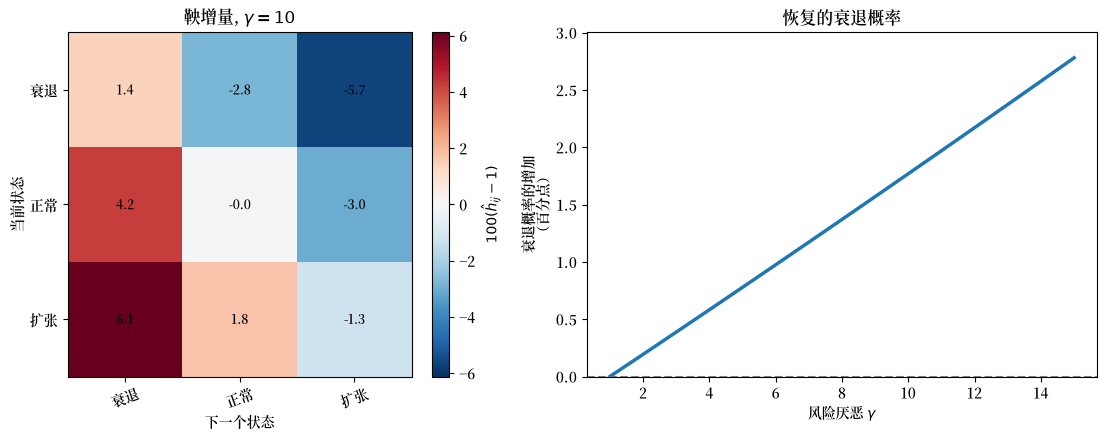

In [7]:
c_recursive = np.array([0.85, 1.00, 1.15])
γ_demo = 10.0
_, _, S_demo = solve_ez_unit_eis(P_true, c_recursive, δ, γ_demo, g_c)
Q_demo = S_demo * P_true
H_demo, _, _, P_hat_demo = martingale_increment(Q_demo, P_true)
H_dev = 100 * (H_demo - 1)

γ_grid = np.linspace(1, 15, 80)
rec_prob = []
for γ in γ_grid:
    _, _, S_g = solve_ez_unit_eis(P_true, c_recursive, δ, γ, g_c)
    Q_g = S_g * P_true
    _, _, _, P_hat_g = martingale_increment(Q_g, P_true)
    rec_prob.append(stationary_dist(P_hat_g)[0])
rec_prob = np.array(rec_prob)
rec_prob_gain = 100 * (rec_prob - π_true[0])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bound = np.max(np.abs(H_dev))
im = axes[0].imshow(H_dev, cmap='RdBu_r', vmin=-bound, vmax=bound)
axes[0].set_xticks(range(3))
axes[0].set_yticks(range(3))
axes[0].set_xticklabels(state_names, rotation=20)
axes[0].set_yticklabels(state_names)
axes[0].set_xlabel('下一个状态')
axes[0].set_ylabel(r'当前状态')
axes[0].set_title(r'鞅增量, $\gamma=10$')

for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{H_dev[i, j]:.1f}",
                     ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04,
             label=r'$100(\hat h_{ij}-1)$')

axes[1].plot(γ_grid, rec_prob_gain, lw=2.5)
axes[1].axhline(0, ls='--', lw=1.5, color='0.5')
axes[1].set_xlabel(r"风险厌恶 $\gamma$")
axes[1].set_ylabel('衰退概率的增加\n（百分点）')
axes[1].set_title('恢复的衰退概率')
axes[1].set_ylim(0, rec_prob_gain.max() * 1.08)

plt.tight_layout()
plt.show()

递归效用使恢复的概率测度对衰退转移赋予更多的概率。

在 $\gamma=10$ 时，转移进入衰退在恢复的概率测度下接收更多的概率，而转移进入扩张接收更少。

随着风险厌恶上升，恢复的概率测度下的平稳衰退概率进一步高于其正确设定的值。

因此，随着延续值项产生非常数的 $\hat h_{ij}$，与长期风险中性概率相关的转移矩阵不再等于正确设定的转移矩阵。

### 永久冲击

递归效用给出了一个非常数的鞅成分。

永久冲击提供了另一个。

假设消费具有永久冲击，

$$
\log C_{t+1}-\log C_t
= g + x(X_{t+1})-x(X_t) + \sigma \varepsilon_{t+1},
$$

其中 $\varepsilon_{t+1}$ 在时间上是独立的。

在幂效用下，SDF 包含

$$
\exp(-\delta-\gamma g)
\exp\{-\gamma[x(X_{t+1})-x(X_t)]\}
\exp(-\gamma\sigma\varepsilon_{t+1}).
$$

中间项仅依赖于当前和下一个马尔可夫状态。

它是状态函数之比，因此佩龙-弗罗贝尼乌斯转移公式可以抵消它。

永久冲击项依赖于新的冲击 $\varepsilon_{t+1}$。

因为在这个构造中该冲击不能由有限马尔可夫状态概括，所以没有状态函数的比值可以抵消它。

除以其条件均值后，冲击项变成一个鞅增量：

$$
\frac{\exp(-\gamma\sigma\varepsilon_{t+1})}
     {E[\exp(-\gamma\sigma\varepsilon_{t+1})]}.
$$

因此，即使在普通的幂效用下，永久消费冲击也能使恢复的概率测度不同于投资者的信念。

这个陈述是相对于恢复过程中使用的马尔可夫状态而言的。

扩大状态或信息结构以考虑该冲击可以容纳它，但这样做会导致 {ref}`mr_additional_state` 中讨论的识别问题。

### 长期风险

我们现在从小的有限状态例子转向一个标准的连续时间宏观金融模型。

该模型是 Bansal-Yaron 长期风险模型，使用 {cite:t}`BorovickaHansenScheinkman2016` 报告的校准。

目的是在一个标准的宏观金融模型中比较恢复的概率测度与正确设定的概率测度。

构造具有与之前相同的结构。

我们首先写下正确设定的状态动态，然后计算佩龙-弗罗贝尼乌斯方法所隐含的概率测度。

状态向量 $X_t=(X_{1t},X_{2t})'$ 遵循

$$
\begin{aligned}
dX_{1t}
&= [\mu_{11}(X_{1t}-\iota_1)+\mu_{12}(X_{2t}-\iota_2)]dt
   + \sqrt{X_{2t}}\sigma_1 dW_t, \\
dX_{2t}
&= \mu_{22}(X_{2t}-\iota_2)dt
   + \sqrt{X_{2t}}\sigma_2 dW_t .
\end{aligned}
$$

这里 $X_1$ 是可预测的消费增长，$X_2$ 是随机波动率。

代表性行为人具有单位跨期替代弹性的 Epstein-Zin 效用。

延续值引入了上面鞅成分的连续时间类比。

我们将该过程记为 $H^*$，SDF 满足

$$
d\log S_t = -\delta dt - d\log C_t + d\log H_t^*.
$$

这里 $H^*$ 是进入 Epstein-Zin SDF 的延续值鞅。

与佩龙-弗罗贝尼乌斯问题相关的乘性鞅 $\hat H$ 只有在同时纳入佩龙-弗罗贝尼乌斯特征函数之后才能得到。

在消费增长中带有鞅成分的模型中，$H^*$ 和 $\hat H$ 不必一致。

下一个单元设定校准。

In [8]:
lrr_params = dict(
    δ=0.002,
    γ=10.0,
    μ11=-0.021,
    μ12=0.0,
    μ22=-0.013,
    ι1=0.0,
    ι2=1.0,
    σ1=np.array([0.0, 0.00034, 0.0]),
    σ2=np.array([0.0, 0.0, -0.038]),
    β_c0=0.0015,
    β_c1=1.0,
    β_c2=0.0,
    α_c=np.array([0.0078, 0.0, 0.0]),
)

下一个代码块计算不同的概率测度如何改变状态向量的漂移。

第一个量是延续值。

在这个仿射模型中，平移后的延续值是状态的线性函数：

$$
v(x) = v_0 + v_1 x_1 + v_2 x_2.
$$

这就是为什么我们称 $v_1$ 和 $v_2$ 为斜率。

它们是延续值关于可预测增长和波动率的导数。

这些斜率进入延续值鞅 $H^*$。

在代码中，这个鞅具有冲击暴露

$$
\alpha_{H^*}
= (1-\gamma)(\alpha_c + \sigma_1 v_1 + \sigma_2 v_2).
$$

由于 SDF 是 $d\log S_t=-\delta dt-d\log C_t+d\log H_t^*$，其冲击暴露为

$$
\alpha_S = -\alpha_c + \alpha_{H^*}.
$$

这个向量 $\alpha_S$ 驱动单期风险中性测度变换。

第二个量是佩龙-弗罗贝尼乌斯特征函数。

它是指数仿射的：

$$
\hat e(x) = \exp(e_0 + e_1 x_1 + e_2 x_2).
$$

因此 $e_1$ 和 $e_2$ 是对数特征函数的斜率。

因为 $X_1$ 和 $X_2$ 具有冲击载荷 $\sigma_1$ 和 $\sigma_2$，佩龙-弗罗贝尼乌斯特征函数贡献了额外的冲击暴露

$$
\sigma_1 e_1 + \sigma_2 e_2.
$$

因此，单期风险中性动态仅使用 $\alpha_S$，而长期风险中性测度下的动态使用

$$
\alpha_S + \sigma_1 e_1 + \sigma_2 e_2.
$$

下面的函数遵循此顺序：计算 $(v_1, v_2)$，计算 $\alpha_S$ 和 $(e_1, e_2)$，然后将这些冲击暴露转化为 $X$ 的漂移。

In [9]:
def solve_value_function(p):
    """仿射延续值的斜率。"""
    δ, γ = p["δ"], p["γ"]
    μ11, μ12, μ22 = p["μ11"], p["μ12"], p["μ22"]
    σ1, σ2 = p["σ1"], p["σ2"]
    β_c1, β_c2 = p["β_c1"], p["β_c2"]
    α_c = p["α_c"]

    # v1 是 v(x) 中可预测增长的系数。
    v1 = β_c1 / (δ - μ11)

    # v2 是波动率的系数。
    # 在仿射模型中它是一个标量二次方程的稳定根。
    A_vec = α_c + σ1 * v1
    B_vec = σ2

    a = 0.5 * (1 - γ) * np.dot(B_vec, B_vec)
    b = (μ22 - δ) + (1 - γ) * np.dot(A_vec, B_vec)
    c = β_c2 + μ12 * v1 + 0.5 * (1 - γ) * np.dot(A_vec, A_vec)

    disc = b**2 - 4 * a * c
    if disc < 0:
        raise ValueError("Value function does not exist for these parameters.")

    v2 = (-b - np.sqrt(disc)) / (2 * a)
    return v1, v2


def solve_pf_lrr(p, v1, v2):
    """佩龙-弗罗贝尼乌斯特征函数斜率和 SDF 扩散载荷。"""
    δ, γ = p["δ"], p["γ"]
    μ11, μ12, μ22 = p["μ11"], p["μ12"], p["μ22"]
    ι1, ι2 = p["ι1"], p["ι2"]
    σ1, σ2 = p["σ1"], p["σ2"]
    α_c = p["α_c"]
    β_c0, β_c1, β_c2 = p["β_c0"], p["β_c1"], p["β_c2"]

    # 延续值鞅暴露和 SDF 暴露。
    α_h_star = (1 - γ) * (α_c + σ1 * v1 + σ2 * v2)
    α_s = -α_c + α_h_star

    # 佩龙-弗罗贝尼乌斯分解之前 log S 的漂移系数。
    β_s11 = -β_c1
    β_s12 = -β_c2 - 0.5 * np.dot(α_h_star, α_h_star)
    β_s0 = -δ - β_c0 - 0.5 * ι2 * np.dot(α_h_star, α_h_star)

    # e1 和 e2 是 log e(x) = e0 + e1 x1 + e2 x2 中的系数。
    e1 = -β_s11 / μ11

    # e2 求解来自佩龙-弗罗贝尼乌斯特征值方程的剩余二次方程。
    const = (β_s12 + 0.5 * np.dot(α_s, α_s)
             + e1 * (μ12 + np.dot(σ1, α_s))
             + 0.5 * e1**2 * np.dot(σ1, σ1))
    lin = μ22 + np.dot(σ2, α_s) + e1 * np.dot(σ1, σ2)
    quad = 0.5 * np.dot(σ2, σ2)

    disc = lin**2 - 4 * quad * const
    roots = [(-lin - np.sqrt(disc)) / (2 * quad),
             (-lin + np.sqrt(disc)) / (2 * quad)]

    candidates = []
    for e2 in roots:
        eta = (β_s0 - β_s11 * ι1 - β_s12 * ι2
               - e1 * (μ11 * ι1 + μ12 * ι2) - e2 * μ22 * ι2)
        candidates.append((eta, e2))

    # 选择给出较小特征值指数的解。
    eta, e2 = min(candidates)
    return e1, e2, eta, α_s


def recovered_lrr_dynamics(p, e1, e2, α_s):
    """长期风险中性测度下的状态动态。"""
    μ11, μ12, μ22 = p["μ11"], p["μ12"], p["μ22"]
    ι1, ι2 = p["ι1"], p["ι2"]
    σ1, σ2 = p["σ1"], p["σ2"]

    # 长期风险中性测度使用 SDF 暴露加上特征函数暴露。
    α_h = α_s + σ1 * e1 + σ2 * e2

    # 扩散测度变换将每个漂移移动 sigma_i 点乘 alpha_h。
    μ_hat_11 = μ11
    μ_hat_12 = μ12 + np.dot(σ1, α_h)
    μ_hat_22 = μ22 + np.dot(σ2, α_h)

    # 用均值回复形式重写移动后的漂移。
    ι_hat_2 = (μ22 / μ_hat_22) * ι2
    ι_hat_1 = ι1 + (μ12 * ι2 - μ_hat_12 * ι_hat_2) / μ11

    return dict(
        μ11=μ_hat_11,
        μ12=μ_hat_12,
        μ22=μ_hat_22,
        ι1=ι_hat_1,
        ι2=ι_hat_2,
        σ1=σ1,
        σ2=σ2,
        α_h=α_h,
    )


def risk_neutral_lrr_dynamics(p, α_s):
    """单期风险中性测度下的状态动态。"""
    μ11, μ12, μ22 = p["μ11"], p["μ12"], p["μ22"]
    ι1, ι2 = p["ι1"], p["ι2"]
    σ1, σ2 = p["σ1"], p["σ2"]

    # 单期风险中性测度仅使用 SDF 暴露。
    μ_bar_11 = μ11
    μ_bar_12 = μ12 + np.dot(σ1, α_s)
    μ_bar_22 = μ22 + np.dot(σ2, α_s)

    # 用均值回复形式重写移动后的漂移。
    ι_bar_2 = (μ22 / μ_bar_22) * ι2
    ι_bar_1 = ι1 + (μ12 * ι2 - μ_bar_12 * ι_bar_2) / μ11

    return dict(
        μ11=μ_bar_11,
        μ12=μ_bar_12,
        μ22=μ_bar_22,
        ι1=ι_bar_1,
        ι2=ι_bar_2,
        σ1=σ1,
        σ2=σ2,
    )

对于这里使用的校准，恢复的概率测度改变了长期状态分布。

它降低了预期增长的均值并提高了波动率的均值。

In [10]:
v1, v2 = solve_value_function(lrr_params)
e1, e2, η_lrr, α_s = solve_pf_lrr(lrr_params, v1, v2)
dyn_hat = recovered_lrr_dynamics(lrr_params, e1, e2, α_s)
dyn_bar = risk_neutral_lrr_dynamics(lrr_params, α_s)

print(f"值斜率:       v1 = {v1:.4f}, v2 = {v2:.4f}")
print(f"特征函数系数: e1 = {e1:.4f}, e2 = {e2:.4f}")
print(f"对数特征值:     eta = {η_lrr:.6f}  "
      f"(年化 {12 * η_lrr:.4f})")
print()
print("三种测度下的长期均值")
print("测度        iota_1     iota_2     mu_12      mu_22")
print("---------   --------   --------   --------   --------")
print(f"实际        {lrr_params['ι1']:8.5f}   {lrr_params['ι2']:8.5f}"
      f"   {lrr_params['μ12']:8.5f}   {lrr_params['μ22']:8.5f}")
print(f"单期        {dyn_bar['ι1']:8.5f}   {dyn_bar['ι2']:8.5f}"
      f"   {dyn_bar['μ12']:8.5f}   {dyn_bar['μ22']:8.5f}")
print(f"长期        {dyn_hat['ι1']:8.5f}   {dyn_hat['ι2']:8.5f}"
      f"   {dyn_hat['μ12']:8.5f}   {dyn_hat['μ22']:8.5f}")

值斜率:       v1 = 43.4783, v2 = -0.0871
特征函数系数: e1 = -47.6190, e2 = 0.2449
对数特征值:     eta = -0.000316  (年化 -0.0038)

三种测度下的长期均值
测度        iota_1     iota_2     mu_12      mu_22
---------   --------   --------   --------   --------
实际         0.00000    1.00000    0.00000   -0.01300
单期        -0.00236    1.09537   -0.00005   -0.01187
长期        -0.00273    1.12901   -0.00005   -0.01151


这些数值清楚地展示了这个机制。

正的值斜率 $v_1$ 表明延续值对可预测的消费增长非常敏感。

在这个校准中波动率斜率 $v_2$ 为负，因此更高的波动率降低延续值。

特征函数系数 $e_1$ 具有相反的符号：长期测度变换对可预测增长具有负载荷。

因此恢复的概率测度对具有较低预期增长的历史赋予更多的概率。

正的 $e_2$ 对波动率具有相反的含义，对更高波动率状态赋予更多的概率。

该表将那些系数转化为状态动态。

相对于正确设定的概率测度，两个风险中性测度都降低了可预测增长的长期均值并提高了波动率的长期均值。

长期风险中性测度在那个方向上移动得比单期风险中性测度更远：$\iota_1$ 从 $0$ 下降到约 $-0.0027$，而 $\iota_2$ 从 $1$ 上升到约 $1.13$。

小的负对数特征值意味着 $\exp(\eta)$ 略低于一；按照通常的收益率符号约定，$-\eta$ 是对应的长期贴现率。

#### 平稳密度

系数表给出了概率测度之间差异的一个概括。

平稳密度图给出了另一个。

它不仅显示 $X_1$ 和 $X_2$ 的均值移动，还显示增长和波动率的哪些组合变得更可能。

这很重要，因为将恢复的概率测度视为信念改变了整个预测分布，而不仅仅是一对长期平均值。

在恢复的概率测度下，概率质量向不利的长期风险状态转移。

这些是具有较低可预测增长 $X_1$ 和较高波动率 $X_2$ 的状态。

虚线轮廓添加了单期风险中性概率测度。

在这个校准中，单期风险中性和长期风险中性平稳分布彼此接近，且两者都远离正确设定的分布。

因此，鞅成分解释了状态动态中大部分的风险调整。

该论文的图 1 报告了模型隐含的平稳密度；下面的模拟是对那些密度的数值近似。

下图模拟每个概率测度下的状态过程，并估计 $(X_2, X_1)$ 的平稳联合密度。

水平线标记 $X_1=0$，垂直线标记正确设定的波动率均值 $X_2=\iota_2$。

findfont: Failed to find font weight normal, now using 600.


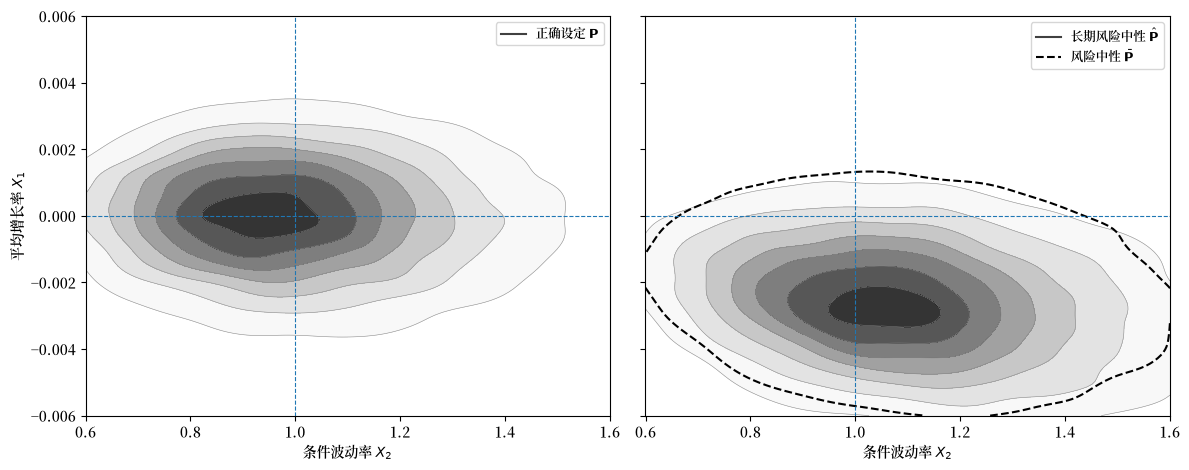

In [11]:
def simulate_lrr(dyn, T=180_000, seed=123):
    """
    在一个概率测度下对 LRR 状态过程进行欧拉模拟。
    """
    rng = np.random.default_rng(seed)
    X1 = np.zeros(T)
    X2 = np.full(T, dyn["ι2"])

    # 以月度时间增量进行欧拉步
    for t in range(1, T):
        X2_prev = max(X2[t-1], 1e-9)
        dW = rng.standard_normal(3)
        sqrt_X2 = np.sqrt(X2_prev)

        X1[t] = (
            X1[t-1]
            + dyn["μ11"] * (X1[t-1] - dyn["ι1"])
            + dyn["μ12"] * (X2_prev - dyn["ι2"])
            + sqrt_X2 * np.dot(dyn["σ1"], dW)
        )
        X2[t] = max(
            X2_prev
            + dyn["μ22"] * (X2_prev - dyn["ι2"])
            + sqrt_X2 * np.dot(dyn["σ2"], dW),
            1e-9,
        )

    burn = T // 5
    return X1[burn:], X2[burn:]


def kde2d_contour(ax, X1, X2, label, levels=7, fill=True,
                  linestyle='solid', outer_only=False):
    """估计平稳密度并绘制其等高线。"""
    m = min(25_000, len(X1))
    idx = np.linspace(0, len(X1) - 1, m, dtype=int)
    x1 = X1[idx]
    x2 = X2[idx]

    kde = gaussian_kde(np.vstack([x2, x1]))
    x2_grid = np.linspace(0.6, 1.6, 140)
    x1_grid = np.linspace(-0.006, 0.006, 140)
    X2g, X1g = np.meshgrid(x2_grid, x1_grid)
    Z = kde(np.vstack([X2g.ravel(), X1g.ravel()])).reshape(X2g.shape)

    contour_levels = np.linspace(0.12 * Z.max(), 0.9 * Z.max(), levels)
    if outer_only:
        contour_levels = contour_levels[:1]

    if fill:
        fill_levels = np.r_[contour_levels, Z.max()]
        ax.contourf(X2g, X1g, Z, levels=fill_levels, cmap='Greys',
                    alpha=0.85)
        ax.contour(X2g, X1g, Z, levels=contour_levels, colors='0.55',
                   linewidths=0.4)
        ax.plot([], [], color='0.25', lw=1.5, label=label)
    else:
        ax.contour(X2g, X1g, Z, levels=contour_levels, colors='black',
                   linewidths=1.5, linestyles=linestyle)
        ax.plot([], [], color='black', lw=1.5, ls=linestyle, label=label)


dyn_true = dict(
    μ11=lrr_params["μ11"],
    μ12=lrr_params["μ12"],
    μ22=lrr_params["μ22"],
    ι1=lrr_params["ι1"],
    ι2=lrr_params["ι2"],
    σ1=lrr_params["σ1"],
    σ2=lrr_params["σ2"],
)

X1_P, X2_P = simulate_lrr(dyn_true, seed=1)
X1_H, X2_H = simulate_lrr(dyn_hat, seed=2)
X1_B, X2_B = simulate_lrr(dyn_bar, seed=3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, sharey=True)
kde2d_contour(axes[0], X1_P, X2_P, label=r'正确设定 $\mathbf{P}$')
kde2d_contour(axes[1], X1_H, X2_H,
              label=r'长期风险中性 $\hat{\mathbf{P}}$')
kde2d_contour(axes[1], X1_B, X2_B,
              label=r'风险中性 $\bar{\mathbf{P}}$',
              fill=False, linestyle='--', outer_only=True)

for ax in axes:
    ax.axhline(0, lw=0.8, ls='--')
    ax.axvline(lrr_params["ι2"], lw=0.8, ls='--')
    ax.set_xlim(0.6, 1.6)
    ax.set_ylim(-0.006, 0.006)
    ax.set_xlabel(r"条件波动率 $X_2$")
    ax.legend(fontsize=9)

axes[0].set_ylabel(r"平均增长率 $X_1$")
plt.tight_layout()
plt.show()

水平线以下的移动意味着较低的预期增长，而垂直线右侧的移动意味着较高的波动率。

#### 收益率含义

概率测度之间的差异对资产定价诠释很重要，因为收益率混合了两个量：一个收益预测和一个资产价格。

恢复的概率测度被称为长期风险中性，因为它吸收了给长视界风险定价的鞅成分。

对于随机增长的现金流，该论文的长视界结果是，在恢复的概率测度下，相对于期限匹配债券的风险溢价消失，这取决于用于极限的稳定性和矩条件。

在正确设定的概率测度下，那些相同的长期风险溢价不必消失。

对于现金流 $G_t$，将正确设定的概率测度下的期望记为 $E_P$，将恢复的概率测度下的期望记为 $E_{\hat P}$。

在正确设定的概率测度下计算的收益率为

$$
y_t^P[G](x)
= \frac{1}{t}\log E_P[G_t \mid X_0=x]
  - \frac{1}{t}\log E_P[S_tG_t \mid X_0=x].
$$

第一项是收益预测。

第二项是资产价格，用原始 SDF 表示写成。

阿罗价格决定第二项。

这里的问题是，如果分析师将恢复的概率测度 $\hat{\mathbf{P}}$ 视为投资者的信念，第一项会发生什么。

在那个比较中，价格保持固定，只重新计算预测项：

$$
y_t^{\hat P}[G](x)
= \frac{1}{t}\log E_{\hat P}[G_t \mid X_0=x]
  - \frac{1}{t}\log E_P[S_tG_t \mid X_0=x].
$$

对于总消费收益，答案是显著的。

恢复的概率测度对低增长、高波动率状态赋予更多的概率，因此它预测更低的未来消费。

保持价格固定，那个较低的预测转化为较低的消费收益率。

零息债券是比较情形。

它的收益是一，因此预测项总是 $\log E[1]=0$。

因此改变信念不会移动债券收益率图。

同一个佩龙-弗罗贝尼乌斯问题的解也出现在长债券和远期测度极限中。

极长债券的极限单期回报为

$$
R^\infty_{t,t+1}
= \exp(-\hat\eta)\frac{\hat e(X_{t+1})}{\hat e(X_t)}.
$$

鞅增量满足

$$
\frac{\hat H_{t+1}}{\hat H_t}
= \frac{S_{t+1}}{S_t} R^\infty_{t,t+1}.
$$

因此来自远期测度的极限单期转移与长期风险中性概率相关的转移一致。

下面的计算使用长期风险模型隐含的仿射公式。

如果乘性泛函 $M$ 具有关于 $X$ 仿射的对数漂移和与 $\sqrt{X_2}$ 成比例的扩散，那么

$$
E[M_t \mid X_0=x]
= \exp\{\theta_0(t)+\theta_1(t)x_1+\theta_2(t)x_2\},
$$

其中系数求解里卡蒂方程。

下面的代码在正确设定的测度下计算这些仿射期望，仅在恢复的概率测度下重新计算消费预测，并保持资产价格固定。

然后它在相同的模拟初始状态上绘制中位数和四分位区间收益率带。

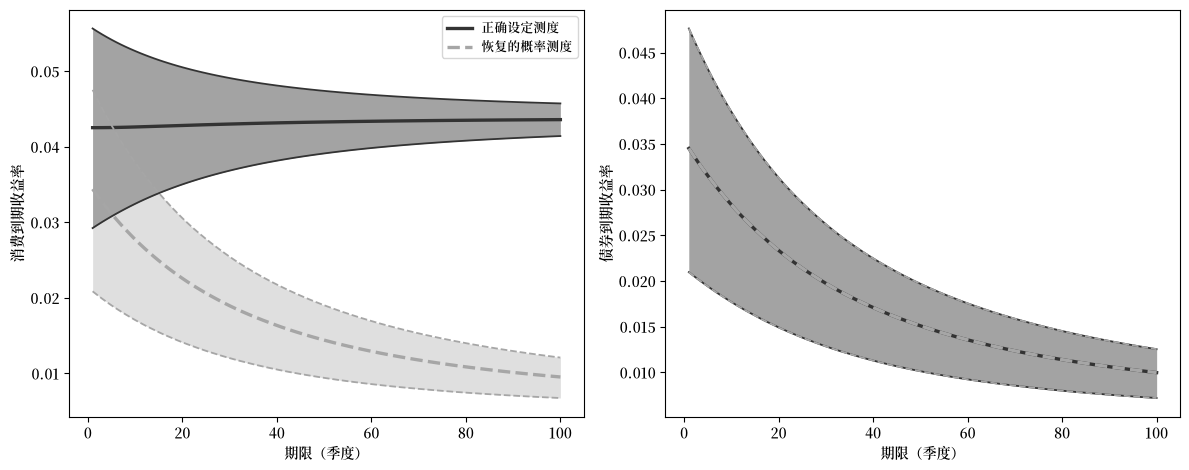

In [12]:
def affine_expectation_coeffs(dyn, β0, β1, β2, α, horizons):
    """log E[M_t | X_0=x] 的里卡蒂系数。"""
    μ11, μ12, μ22 = dyn["μ11"], dyn["μ12"], dyn["μ22"]
    ι1, ι2 = dyn["ι1"], dyn["ι2"]
    σ1, σ2 = dyn["σ1"], dyn["σ2"]

    def ode(_, θ):
        θ0, θ1, θ2 = θ
        θ0_dot = (β0 - β1 * ι1 - β2 * ι2
                  - θ1 * (μ11 * ι1 + μ12 * ι2)
                  - θ2 * μ22 * ι2)
        θ1_dot = β1 + μ11 * θ1
        θ2_dot = (β2 + μ12 * θ1 + μ22 * θ2
                  + 0.5 * np.dot(α, α)
                  + θ1 * np.dot(σ1, α)
                  + θ2 * np.dot(σ2, α)
                  + 0.5 * θ1**2 * np.dot(σ1, σ1)
                  + θ1 * θ2 * np.dot(σ1, σ2)
                  + 0.5 * θ2**2 * np.dot(σ2, σ2))
        return [θ0_dot, θ1_dot, θ2_dot]

    sol = solve_ivp(ode, (0, horizons[-1]), np.zeros(3),
                    t_eval=horizons, rtol=1e-8, atol=1e-10)
    if not sol.success:
        raise ValueError("Riccati equation failed to solve")
    return sol.y.T


def log_expectation(θ, X1, X2):
    """在模拟状态上求 log E[M_t | X_0=x]。"""
    return θ[:, 0, None] + θ[:, 1, None] * X1[None, :] + θ[:, 2, None] * X2[None, :]


def yield_quantiles(log_num, log_den, horizons):
    """跨初始状态的年化收益率的四分位数。"""
    yields = 12 * (log_num - log_den) / horizons[:, None]
    return np.quantile(yields, [0.25, 0.5, 0.75], axis=1)


def transform_functional(β0, β1, β2, α, dyn_old, dyn_new, α_h):
    """改变概率后重写乘性泛函。"""
    # 漂移改变是因为鞅成分改变了用于预测现金流的
    # 布朗冲击暴露。
    β_level = β0 - β1 * dyn_old["ι1"] - β2 * dyn_old["ι2"]
    β2_new = β2 + np.dot(α, α_h)
    β0_new = β_level + β1 * dyn_new["ι1"] + β2_new * dyn_new["ι2"]
    return β0_new, β1, β2_new, α


def sdf_coefficients(p, v1, v2):
    """仿射期望计算中使用的 SDF 系数。"""
    δ, γ = p["δ"], p["γ"]
    α_c, σ1, σ2 = p["α_c"], p["σ1"], p["σ2"]

    α_h_star = (1 - γ) * (α_c + σ1 * v1 + σ2 * v2)
    α_s = -α_c + α_h_star

    β_s1 = -p["β_c1"]
    β_s2 = -p["β_c2"] - 0.5 * np.dot(α_h_star, α_h_star)
    β_s0 = -δ - p["β_c0"] - 0.5 * p["ι2"] * np.dot(α_h_star, α_h_star)

    return β_s0, β_s1, β_s2, α_s


quarters = np.arange(1, 101)
horizons = 3 * quarters

β_c0, β_c1, β_c2 = (lrr_params["β_c0"],
                    lrr_params["β_c1"],
                    lrr_params["β_c2"])
α_c = lrr_params["α_c"]

β_s0, β_s1, β_s2, α_s = sdf_coefficients(lrr_params, v1, v2)

# 正确设定测度下收益率的分子和分母
θ_C_P = affine_expectation_coeffs(dyn_true, β_c0, β_c1, β_c2, α_c, horizons)
θ_S_P = affine_expectation_coeffs(dyn_true, β_s0, β_s1, β_s2, α_s, horizons)
θ_SC_P = affine_expectation_coeffs(
    dyn_true, β_s0 + β_c0, β_s1 + β_c1, β_s2 + β_c2,
    α_s + α_c, horizons
)

# 恢复的概率测度下总消费收益的分子
β_Ch0, β_Ch1, β_Ch2, α_Ch = transform_functional(
    β_c0, β_c1, β_c2, α_c, dyn_true, dyn_hat, dyn_hat["α_h"]
)
θ_C_H = affine_expectation_coeffs(dyn_hat, β_Ch0, β_Ch1, β_Ch2,
                                  α_Ch, horizons)

log_C_P = log_expectation(θ_C_P, X1_P, X2_P)
log_C_H = log_expectation(θ_C_H, X1_P, X2_P)
log_S_P = log_expectation(θ_S_P, X1_P, X2_P)
log_SC_P = log_expectation(θ_SC_P, X1_P, X2_P)

qC_P = yield_quantiles(log_C_P, log_SC_P, horizons)
qC_H = yield_quantiles(log_C_H, log_SC_P, horizons)
qB_P = yield_quantiles(np.zeros_like(log_S_P), log_S_P, horizons)
# 零息收益在任一信念下都有相同的分子 log E[1] = 0。
qB_H = qB_P.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

def plot_yield_band(ax, x, q, color, label, linestyle='solid',
                    alpha=0.35):
    """绘制四分位区间带和四分位线。"""
    ax.fill_between(x, q[0], q[2], color=color, alpha=alpha, linewidth=0)
    ax.plot(x, q[1], color=color, lw=2.4, ls=linestyle, label=label)
    ax.plot(x, q[0], color=color, lw=1.3, ls=linestyle)
    ax.plot(x, q[2], color=color, lw=1.3, ls=linestyle)


plot_yield_band(axes[0], quarters, qC_P, color='0.2',
                label='正确设定测度', alpha=0.45)
plot_yield_band(axes[0], quarters, qC_H, color='0.65',
                label='恢复的概率测度', linestyle='--', alpha=0.35)
plot_yield_band(axes[1], quarters, qB_P, color='0.2',
                label='正确设定测度', alpha=0.45)
plot_yield_band(axes[1], quarters, qB_H, color='0.65',
                label='恢复的概率测度', linestyle='--', alpha=0.25)

axes[0].set_xlabel('期限（季度）')
axes[0].set_ylabel('消费到期收益率')
axes[1].set_xlabel('期限（季度）')
axes[1].set_ylabel('债券到期收益率')

axes[0].legend(fontsize=9)

plt.tight_layout()
plt.show()

左图是关键：将恢复的概率测度视为信念，对低增长、高波动率状态赋予更多的概率，因此消费的隐含预测更低，当价格保持固定时消费收益率下降。

债券图验证了零息比较。

由于在任何测度下 $\log E[1]=0$，实线和虚线债券收益率带重合。

(mr_additional_state)=
## 额外的状态向量

{cite:t}`BorovickaHansenScheinkman2016` 接着提出扩大状态向量是否会改变恢复问题的问题。

到目前为止，佩龙-弗罗贝尼乌斯特征函数仅依赖于马尔可夫状态 $X_t$。

但许多模型还包含一个增长成分 $Y_t$，例如对数消费，其增量由相同的冲击增量驱动。

这里 $\Delta W_{t+1}$ 表示日期 $t$ 和 $t+1$ 之间的冲击增量。

映射 $\phi_x$ 将今天的状态和下一个冲击增量送到明天的状态。

映射 $\phi_y$ 将今天的状态和下一个冲击增量送到 $Y$ 的增量。

$$
X_{t+1}=\phi_x(X_t,\Delta W_{t+1}),
\qquad
Y_{t+1}-Y_t=\phi_y(X_t,\Delta W_{t+1}).
$$

设 $\varepsilon$ 表示一个特征函数候选，它被允许依赖于平稳状态 $X_t$ 和增长成分 $Y_t$。

设 $\zeta$ 是 $Y$ 上的载荷向量，$e_\zeta$ 是 $X$ 的正函数。

那么一个自然的候选是

$$
\varepsilon(x,y)=\exp(\zeta \cdot y)e_\zeta(x).
$$

这种形式很自然，因为 $Y$ 通过增量进入。

沿着一条路径，

$$
\exp(\zeta \cdot Y_{t+1})
= \exp(\zeta \cdot Y_t)
  \exp\{\zeta \cdot (Y_{t+1}-Y_t)\}.
$$

由于 $Y_{t+1}-Y_t$ 是 $(X_t,\Delta W_{t+1})$ 的函数，比值 $\exp(\zeta \cdot Y_{t+1})/\exp(\zeta \cdot Y_t)$ 是一个单期正的乘性泛函增量。

对于固定的 $\zeta$，这个因子将单期定价算子倾斜 $\exp\{\zeta \cdot (Y_{t+1}-Y_t)\}$。

因此依赖于 $x$ 的项并不是简单地重用早先的特征函数。

对于 $\zeta$ 的每个选择，剩余的依赖于 $x$ 的部分求解一个不同的佩龙-弗罗贝尼乌斯问题：

$$
E\left[
    \frac{S_{t+1}}{S_t}
    \exp\{\zeta \cdot (Y_{t+1}-Y_t)\}
    e_\zeta(X_{t+1})
    \mid X_t=x
\right]
=\exp(\eta_\zeta)e_\zeta(x).
$$

改变 $\zeta$ 会改变多少长期增长风险被载入特征函数。

因此，添加 $Y_t$ 可以使主观概率测度成为一个可能的解，但它也创造了一族可能的解。

因此额外的状态变量并不能消除识别问题；它通常使选择问题变得更明确。

该论文还指出了一个相关的实际问题。

高度持久的平稳过程可能难以与具有平稳增量的过程区分。

对于每个有限持久度水平，平稳近似可能对佩龙-弗罗贝尼乌斯问题有唯一解，但随着持久度变得极端，极限问题可能有许多近似解。

在数值上，这意味着恰好在用平稳模型近似随机增长的情形中，佩龙-弗罗贝尼乌斯问题的解可能是敏感的。

然而，有一条结构化的前进道路。

如果分析师提供一个已知与 SDF 具有相同鞅成分的参考乘性泛函 $Y^r$，那么可以将扩大的特征函数限制为形式

$$
(Y^r)^{-1}e(x).
$$

这个限制选择了哪个长期鞅成分被允许进入特征函数。

有了这个额外的结构，阿罗价格可以再次揭示主观概率。

但关键的输入是外部的：长期鞅成分是由分析师提供的，而不是仅从阿罗价格中恢复的。

## 度量鞅成分

该论文还提出鞅成分在资产市场数据中有多大的问题。

在理性预期下，这度量了长期风险调整对估值有多重要。

在主观信念诠释下，只有在施加主观 SDF 本身没有鞅成分之后，它才度量主观信念与正确设定的概率测度之间的差异。

有了那个额外的限制，小的鞅成分会使恢复的概率测度接近信念，而大的鞅成分会使长期风险调整对恢复的概率测度更重要。

一族度量对鞅增量 $\hat H_{t+1}/\hat H_t$ 应用凸函数。

例如，条件相对熵使用

$$
E\left[
    \frac{\hat H_{t+1}}{\hat H_t}
    \log\frac{\hat H_{t+1}}{\hat H_t}
    \mid X_t=x
\right].
$$

这个表达式仅当鞅增量恒等于一时才为零。

在不完整的资产市场数据下，完整的鞅增量不可观测。

因此该论文使用定价限制和长债券回报近似来推导这类差异度量的下界。

这些界是一种方法，用于在不需要完整的阿罗价格集的情况下检验鞅成分在经济上是否很小。

## 教训

佩龙-弗罗贝尼乌斯方法在误设定下仍然有用，但它本身不再解决信念恢复问题。

它给出一个可能包含长视界风险溢价的概率测度。

只有当鞅成分恒等于一时，那个测度才等于投资者的信念。

递归效用、永久冲击和长期风险模型赋予这个鞅一个经济上重要的角色，因此在评估转移独立性对信念恢复的含义时不应忽视它。

## 练习

```{exercise}
:label: ex_misspecified_recovery_martingale_component

**一个两状态鞅成分。**

设

$$
\mathbf{P} =
\begin{pmatrix}
0.8 & 0.2 \\
0.4 & 0.6
\end{pmatrix},
\qquad
\mathbf{Q} =
\begin{pmatrix}
0.72 & 0.15 \\
0.36 & 0.42
\end{pmatrix}.
$$

1. 计算单期风险中性转移矩阵 $\bar{\mathbf{P}}$。
2. 计算与恢复的概率测度相关的转移矩阵 $\hat{\mathbf{P}}$。
3. 计算 $\hat h_{ij}=\hat p_{ij}/p_{ij}$ 并判断恢复是否返回正确设定的转移矩阵。
```

```{solution-start} ex_misspecified_recovery_martingale_component
:class: dropdown
```

这是一个解：

In [13]:
P2 = np.array([[0.8, 0.2],
               [0.4, 0.6]])
Q2 = np.array([[0.72, 0.15],
               [0.36, 0.42]])

Pbar2, qb2 = risk_neutral_probs(Q2)
H2, eta2, e2, Phat2 = martingale_increment(Q2, P2)

print("单期风险中性转移矩阵 P_bar")
print(np.round(Pbar2, 4))
print("\n与恢复的概率测度相关的转移矩阵 P_hat")
print(np.round(Phat2, 4))
print("\n鞅增量 h_hat")
print(np.round(H2, 4))
print("\n恢复返回 P:", np.allclose(H2[P2 > 0], 1))

单期风险中性转移矩阵 P_bar
[[0.8276 0.1724]
 [0.4615 0.5385]]

与恢复的概率测度相关的转移矩阵 P_hat
[[0.8505 0.1495]
 [0.5039 0.4961]]

鞅增量 h_hat
[[1.0631 0.7476]
 [1.2597 0.8269]]

恢复返回 P: False


```{solution-end}
```

```{exercise}
:label: ex_power_utility_success

**幂效用基准。**

对于趋势平稳消费和幂效用，

$$
s_{ij}=A\left(\frac{c_j}{c_i}\right)^{-\gamma}.
$$

证明 $\hat e_i=c_i^\gamma$ 是佩龙-弗罗贝尼乌斯特征向量，且 $\hat{\mathbf{P}}=\mathbf{P}$。

然后使用讲座中的三状态基准进行数值验证。
```

```{solution-start} ex_power_utility_success
:class: dropdown
```

解析检查是：

$$
[\mathbf{Q}\hat e]_i
=\sum_j A\left(\frac{c_j}{c_i}\right)^{-\gamma}p_{ij}c_j^\gamma
=A c_i^\gamma
=A\hat e_i.
$$

因此 $\exp(\hat\eta)=A$ 且

$$
\hat p_{ij}
=\frac{1}{A}q_{ij}\frac{\hat e_j}{\hat e_i}
=p_{ij}.
$$

下面是数值检查。

In [14]:
H_power, _, e_power, P_hat_power = martingale_increment(Q_power, P_true)
e_theory = c_levels**γ_power
e_theory = e_theory / e_theory.sum()

print("佩龙-弗罗贝尼乌斯特征向量")
print(np.round(e_power, 6))
print("\n归一化的 c^gamma")
print(np.round(e_theory, 6))
print("\nmax |P_hat - P|:",
      np.max(np.abs(P_hat_power - P_true)))
print("max |h_hat - 1|:",
      np.max(np.abs(H_power[P_true > 0] - 1)))

佩龙-弗罗贝尼乌斯特征向量
[0.328344 0.333313 0.338343]

归一化的 c^gamma
[0.328344 0.333313 0.338343]

max |P_hat - P|: 6.661338147750939e-16
max |h_hat - 1|: 2.220446049250313e-15


```{solution-end}
```

```{exercise}
:label: ex_recursive_utility_martingale_component

**递归效用和风险厌恶。**

使用带有 $c=(0.85, 1.00, 1.15)$ 的有限状态 Epstein-Zin 例子，计算 $\gamma \in \{1, 5, 10, 15\}$ 时 $\hat{\mathbf{P}}$ 的平稳分布。

随着 $\gamma$ 上升，哪个状态的平稳概率增加最大？
```

```{solution-start} ex_recursive_utility_martingale_component
:class: dropdown
```

这是一个解：

In [15]:
for γ in [1, 5, 10, 15]:
    _, _, S_g = solve_ez_unit_eis(P_true, c_recursive, δ, γ, g_c)
    Q_g = S_g * P_true
    _, _, _, P_hat_g = martingale_increment(Q_g, P_true)
    π_g = stationary_dist(P_hat_g)
    print(f"gamma={γ:2.0f}: {np.round(π_g, 4)}")

print("\n正确设定:", np.round(π_true, 4))

gamma= 1: [0.2688 0.4409 0.2903]
gamma= 5: [0.2766 0.4399 0.2835]
gamma=10: [0.2865 0.4385 0.275 ]
gamma=15: [0.2966 0.4368 0.2666]

正确设定: [0.2688 0.4409 0.2903]


衰退状态的增加最大。

```{solution-end}
```